In [7]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

df = pd.read_csv("top10_per_tp.csv")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df)

     timepoint_ms                image_path  pred_score_mean  pred_score_std  \
0              50            sequin_04s.jpg         0.963081        0.034172   
1              50             navel_03s.jpg         0.939110        0.019659   
2              50            needle_06s.jpg         0.938822        0.016387   
3              50            rosary_03s.jpg         0.937492        0.014589   
4              50              rust_10s.jpg         0.935860        0.010736   
5              50       paper_plate_06s.jpg         0.933029        0.022893   
6              50           shutter_11s.jpg         0.931355        0.014389   
7              50      chicken_wire_07s.jpg         0.929835        0.020379   
8              50  hot-water_bottle_10s.jpg         0.928702        0.016477   
9              50            mallet_12s.jpg         0.928098        0.012318   
10            150             navel_06s.jpg         1.027194        0.014811   
11            150             navel_02s.

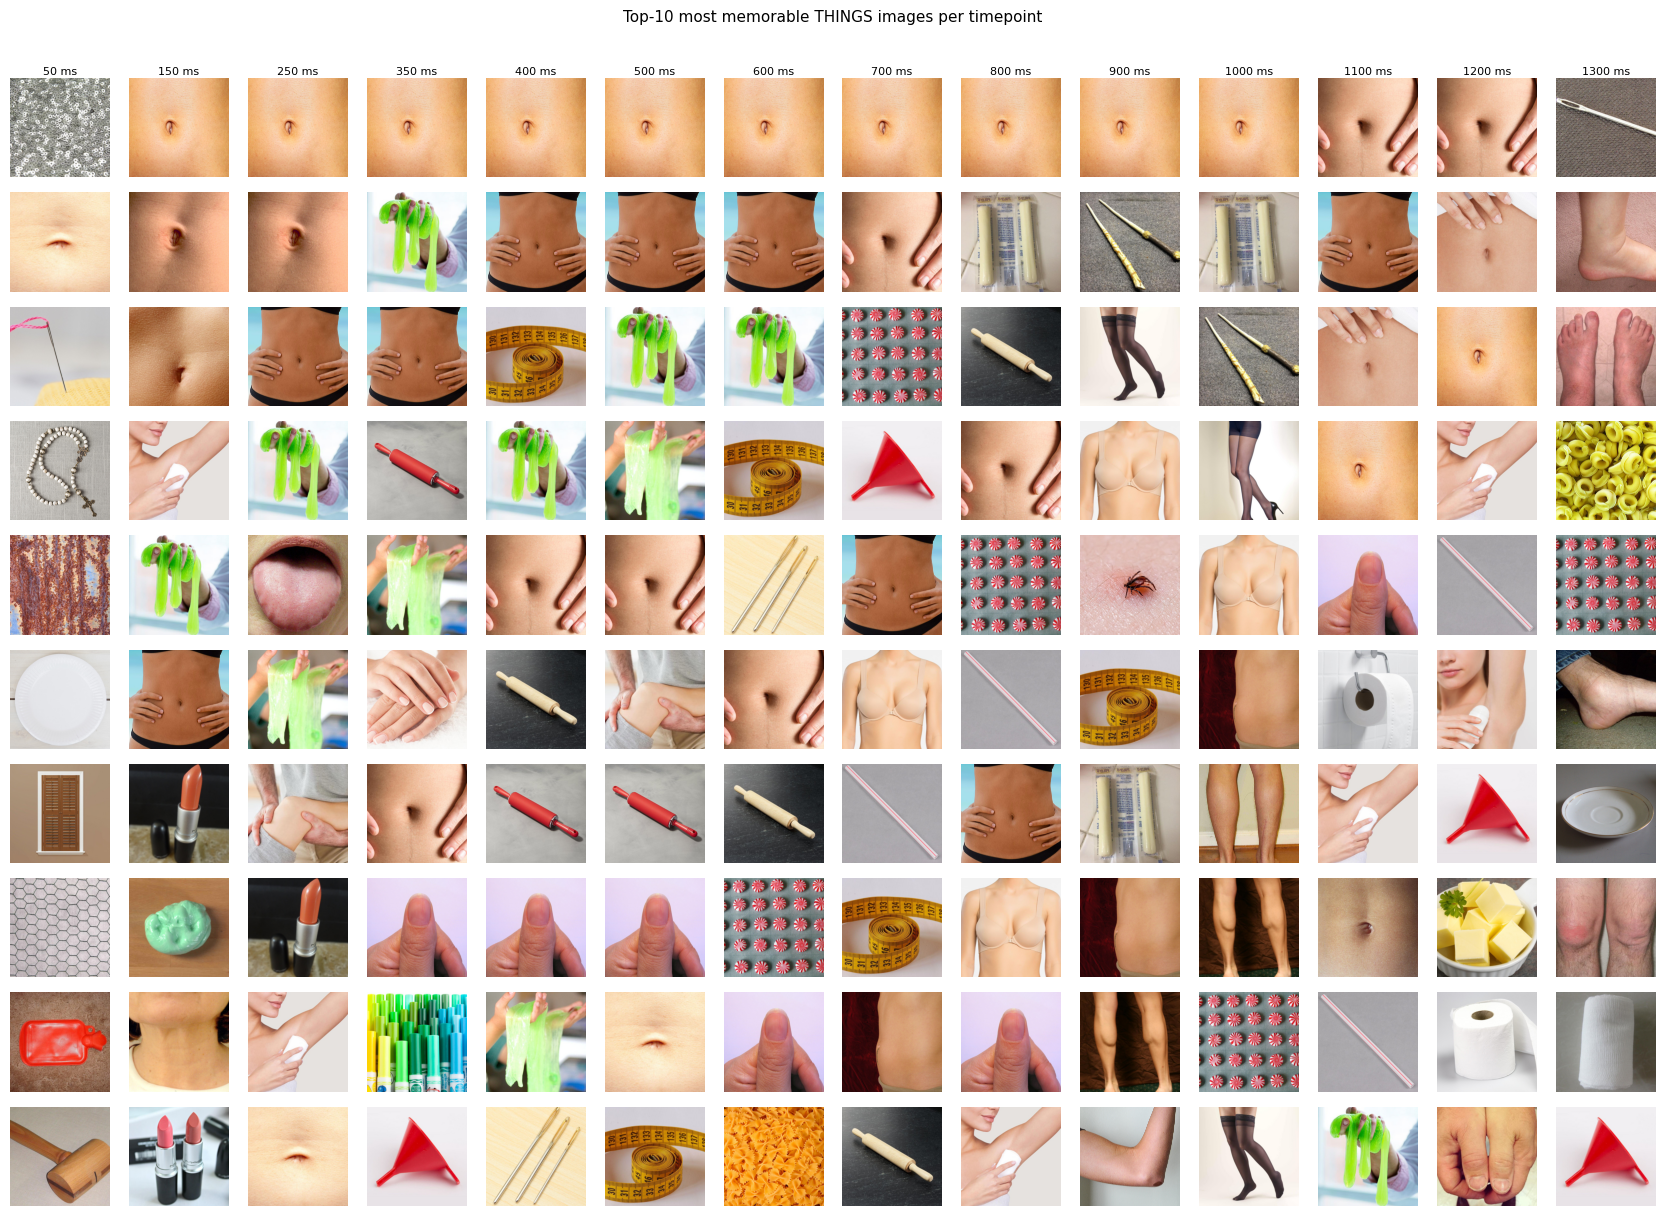

In [5]:
timepoints = sorted(df["timepoint_ms"].unique())
n_tp = len(timepoints)
n_images = 10

img_size = 1.2  # inches per cell
fig, axes = plt.subplots(
    n_images, n_tp,
    figsize=(img_size * n_tp, img_size * n_images),
)

for col, tp in enumerate(timepoints):
    tp_df = df[df["timepoint_ms"] == tp].reset_index(drop=True)
    for row in range(n_images):
        ax = axes[row, col]
        ax.axis("off")
        if row < len(tp_df):
            img_path = tp_df.loc[row, "full_image_path"]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            except FileNotFoundError:
                ax.text(0.5, 0.5, "?", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8, color="red")

    # Label each column with the timepoint at the top
    axes[0, col].set_title(f"{tp} ms", fontsize=8, pad=3)

# Rank labels on the left
for row in range(n_images):
    axes[row, 0].set_ylabel(f"#{row + 1}", fontsize=7, rotation=0,
                            labelpad=18, va="center")

fig.suptitle("Top-10 most memorable THINGS images per timepoint",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("top10_images_per_timepoint.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
ground_truth_scores = pd.read_csv("THINGS_Memorability_Scores.csv")
ground_truth_most_memorable = ground_truth_scores.nlargest(30, "cr")
print(ground_truth_most_memorable)

# save ground truth most memorable dataframe to csv
ground_truth_most_memorable.to_csv("ground_truth_most_memorable.csv", index=False)

       image_nr            image_name  \
3784       3785     candy_bar_04s.jpg   
3930       3931          cape_07s.jpg   
9675       9676       giraffe_06s.jpg   
13479     13480     loincloth_01b.jpg   
16999     17000  plaster_cast_02s.jpg   
19927     19928        seesaw_12s.jpg   
21285     21286          spam_02s.jpg   
21569     21570          spur_03s.jpg   
22859     22860        tamale_06s.jpg   
22973     22974     tarantula_07s.jpg   
23789     23790         torso_05s.jpg   
7830       7831           ear_09s.jpg   
3602       3603         calf2_03s.jpg   
7439       7440      doorstop_10s.jpg   
14878     14879      mustache_13s.jpg   
21539     21540   springboard_13s.jpg   
22763     22764          tack_03s.jpg   
3303       3304        bumper_12s.jpg   
9127       9128     footprint_01b.jpg   
9843       9844          gold_04s.jpg   
11015     11016     headscarf_11s.jpg   
16412     16413    peppermint_07s.jpg   
16880     16881         pipe1_04s.jpg   
18280     18281 